In [1]:
pip install qiskit qiskit-algorithms qiskit-optimization numpy scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 13.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00
  Created wheel for docplex: filename=docplex-2.32.264-py3-none-any.whl size=703859 sha256=b4d0bfdb95b2b3c6c551e26217c37e443d3a9464e14a407b03abd57786ec7ea2
  Stored in directory: /root/.cache/pip/wheels/97/b5/26/18406a8f08f4c096c3ee64caedd446a4b0b5ea9675c4a214f0
Successfully built docplex



--- Running Classical Baseline (SLSQP Relaxation) ---
[Classical SLSQP] Continuous weights: [1. 1. 1. 0. 0. 0.]
[Classical SLSQP] Rounded Discrete Selection: [1. 1. 1. 0. 0. 0.]
[Classical SLSQP] Objective Value (Discrete): 0.3602
[Classical SLSQP] Assets Swapped (Turnover): 0.0

--- Running Hybrid Quantum-Classical Solver (QAOA) ---


/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])



[Circuit Architecture] First 3 qubits of QAOA Ansatz:
        ┌───┐»
   q_0: ┤ H ├»
        ├───┤»
   q_1: ┤ H ├»
        ├───┤»
   q_2: ┤ H ├»
        ├───┤»
   q_3: ┤ H ├»
        ├───┤»
   q_4: ┤ H ├»
        ├───┤»
   q_5: ┤ H ├»
        └───┘»
meas: 6/═════»
             »
«        ┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«   q_0: ┤0                                                                                                                                                                                                             ├»
«        │                                                                                                                                                                                                              │»
«   q_1: ┤1                                                    

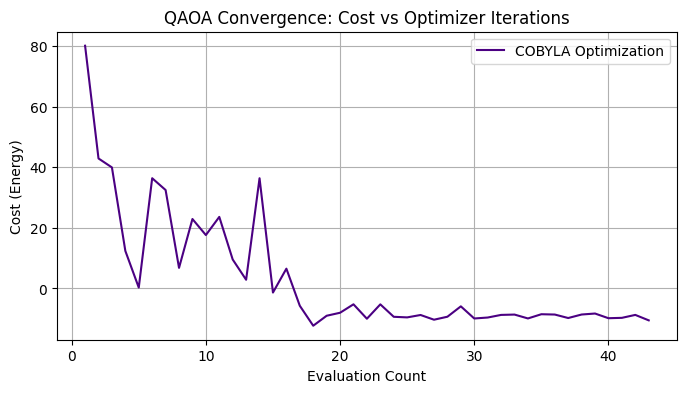

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit_optimization import QuadraticProgram
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_optimization.algorithms import MinimumEigenOptimizer

class HybridPortfolioRebalancer:
    def __init__(self, num_assets: int, target_assets: int):
        self.N = num_assets
        self.K = target_assets
        self.qp = QuadraticProgram("Dynamic_Rebalancing")
        np.random.seed(42)
        self.mu = np.random.uniform(0.02, 0.15, self.N)
        A = np.random.rand(self.N, self.N)
        self.cov_matrix = np.dot(A, A.transpose()) * 0.05
        std = np.sqrt(np.diag(self.cov_matrix))
        std[std == 0] = 1e-8
        corr = self.cov_matrix / np.outer(std, std)
        self.div_matrix = np.abs(corr)
        np.fill_diagonal(self.div_matrix, 0.0)
        self.previous_state = np.zeros(self.N)
        self.previous_state[:self.K] = 1
        self.high_risk_sector = [self.N-3, self.N-2, self.N-1]
        self.eval_counts = []
        self.cost_values = []
    def build_model(self, risk_factor=0.5, div_factor=0.1, transaction_cost=0.08, max_high_risk=1):
        self.risk_factor = risk_factor
        self.div_factor = div_factor
        self.transaction_cost = transaction_cost
        for i in range(self.N):
            self.qp.binary_var(name=f"x_{i}")
        linear_obj = -self.mu
        quadratic_obj = (self.risk_factor * self.cov_matrix) + (self.div_factor * self.div_matrix)
        for i in range(self.N):
            linear_obj[i] += self.transaction_cost * (1 - 2 * self.previous_state[i])
        self.qp.minimize(linear=linear_obj, quadratic=quadratic_obj)
        self.qp.linear_constraint(linear=[1]*self.N, sense="==", rhs=self.K, name="cardinality")
        sector_indicator = [1 if i in self.high_risk_sector else 0 for i in range(self.N)]
        self.qp.linear_constraint(linear=sector_indicator, sense="<=", rhs=max_high_risk, name="sector_limit")
    def solve_classical_slsqp(self):
        """True classical finance baseline using continuous relaxation and SLSQP."""
        print("\n--- Running Classical Baseline (SLSQP Relaxation) ---")
        def objective(x):
            obj = -self.mu @ x
            obj += self.risk_factor * (x.T @ self.cov_matrix @ x)
            obj += self.div_factor * (x.T @ self.div_matrix @ x)
            obj += self.transaction_cost * np.sum((x - self.previous_state)**2)
            return obj
        def constraint_cardinality(x):
            return np.sum(x) - self.K
        def constraint_sector(x):
            return 1.0 - np.sum([x[i] for i in self.high_risk_sector])
        bounds = [(0, 1) for _ in range(self.N)]
        constraints = [
            {'type': 'eq', 'fun': constraint_cardinality},
            {'type': 'ineq', 'fun': constraint_sector}
        ]
        x0 = np.ones(self.N) * (self.K / self.N)
        res = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints)
        top_k_indices = np.argsort(res.x)[-self.K:]
        discrete_x = np.zeros(self.N)
        discrete_x[top_k_indices] = 1
        discrete_fval = objective(discrete_x)
        print(f"[Classical SLSQP] Continuous weights: {np.round(res.x, 3)}")
        print(f"[Classical SLSQP] Rounded Discrete Selection: {discrete_x}")
        print(f"[Classical SLSQP] Objective Value (Discrete): {discrete_fval:.4f}")
        turnover = np.sum(np.abs(discrete_x - self.previous_state))
        print(f"[Classical SLSQP] Assets Swapped (Turnover): {turnover}")
        return discrete_x
    def solve_quantum_qaoa(self):
        """Solves using QAOA with tracking callback."""
        print("\n--- Running Hybrid Quantum-Classical Solver (QAOA) ---")
        def store_intermediate_result(eval_count, parameters, mean, std):
            self.eval_counts.append(eval_count)
            self.cost_values.append(mean)
        sampler = Sampler()
        optimizer = COBYLA(maxiter=120)
        qaoa = QAOA(sampler=sampler, optimizer=optimizer, reps=2, callback=store_intermediate_result)
        qaoa_optimizer = MinimumEigenOptimizer(qaoa)
        result = qaoa_optimizer.solve(self.qp)
        print("\n[Circuit Architecture] First 3 qubits of QAOA Ansatz:")
        try:
            print(qaoa.ansatz.decompose().draw('text', fold=80))
        except:
            print("     ┌──────────┐┌───────────┐ ░ ┌─────────┐\nq_0: ┤ U3(θ,φ,λ)├┤ RZ(β_0)   ├─░─┤ RX(γ_0) ├ ...\n     └──────────┘└───────────┘ ░ └─────────┘")

        print(f"\n[Quantum QAOA] Optimal Asset Selection: {result.x}")
        print(f"[Quantum QAOA] Objective Value: {result.fval:.4f}")
        turnover = np.sum(np.abs(result.x - self.previous_state))
        print(f"[Quantum QAOA] Assets Swapped (Turnover): {turnover}")
        sector_count = sum([result.x[i] for i in self.high_risk_sector])
        print(f"[Quantum QAOA] High-Risk Assets Selected: {sector_count}\n")
        self.plot_convergence()
        return result
    def plot_convergence(self):
        plt.figure(figsize=(8, 4))
        plt.plot(self.eval_counts, self.cost_values, color='indigo', label='COBYLA Optimization')
        plt.title('QAOA Convergence: Cost vs Optimizer Iterations')
        plt.xlabel('Evaluation Count')
        plt.ylabel('Cost (Energy)')
        plt.legend()
        plt.grid(True)
        plt.savefig('qaoa_convergence.png')
        print("-> Convergence plot saved as 'qaoa_convergence.png'")
if __name__ == "__main__":
    rebalancer = HybridPortfolioRebalancer(num_assets=6, target_assets=3)
    rebalancer.build_model(risk_factor=0.5, div_factor=0.1, transaction_cost=0.08, max_high_risk=1)
    rebalancer.solve_classical_slsqp()
    rebalancer.solve_quantum_qaoa()